<a href="https://colab.research.google.com/github/aslater-mc/aslater---DATA-110-22016/blob/DATA-110-Assignments/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import plotly.express as px
from folium.plugins import HeatMap

In [ ]:
#Because of the nature of this dataset, I went in and cleaned up the victim_age section so that it would be considered a int64 dtype. I removed the wordy statements such as "99 years or older" and "under one years old", replacing them with numerical values. For transparency, I've made sure to note this here.
dtype_dict = {'us_gun_deathsFFE': 'str', 'victim_age': 'float64'}
df = pd.read_csv('/content/us_gun_deathsFFE.csv', dtype=dtype_dict)
plt.show()
#The cleaned and modified dataset is renamed with the 'FFE' suffix to clarify that's been modified for File Formating Ease.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389730 entries, 0 to 389729
Data columns (total 21 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   Unnamed: 0                                 389730 non-null  int64  
 1   year                                       389730 non-null  int64  
 2   month                                      389730 non-null  int64  
 3   region                                     389730 non-null  object 
 4   state                                      389730 non-null  object 
 5   victim_age                                 385320 non-null  float64
 6   victim_sex                                 389730 non-null  object 
 7   victim_race                                389730 non-null  object 
 8   victim_race_plus_hispanic                  389730 non-null  object 
 9   victim_ethnicity                           389730 non-null  object 
 10  weapon_u

In [427]:
#Global Style Paramaters
#I wanted to make it easier to have a concise color style to use that is consistent with all of my plots but still allow me to step in and edit as needed.
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.monospace'] = ['courier'] + plt.rcParams['font.monospace']
plt.rc('axes',edgecolor='green')
plt.rc('axes',labelcolor='forestgreen')
plt.rc('axes', facecolor='white')
plt.rc('axes', titlecolor='forestgreen')
plt.rc('xtick',color='seagreen')
plt.rc('ytick',color='seagreen')
plt.rc('grid', alpha=0.5, linestyle='dotted', color='darkgreen')




In [ ]:
#Incidents by Year (IBY) Analysis

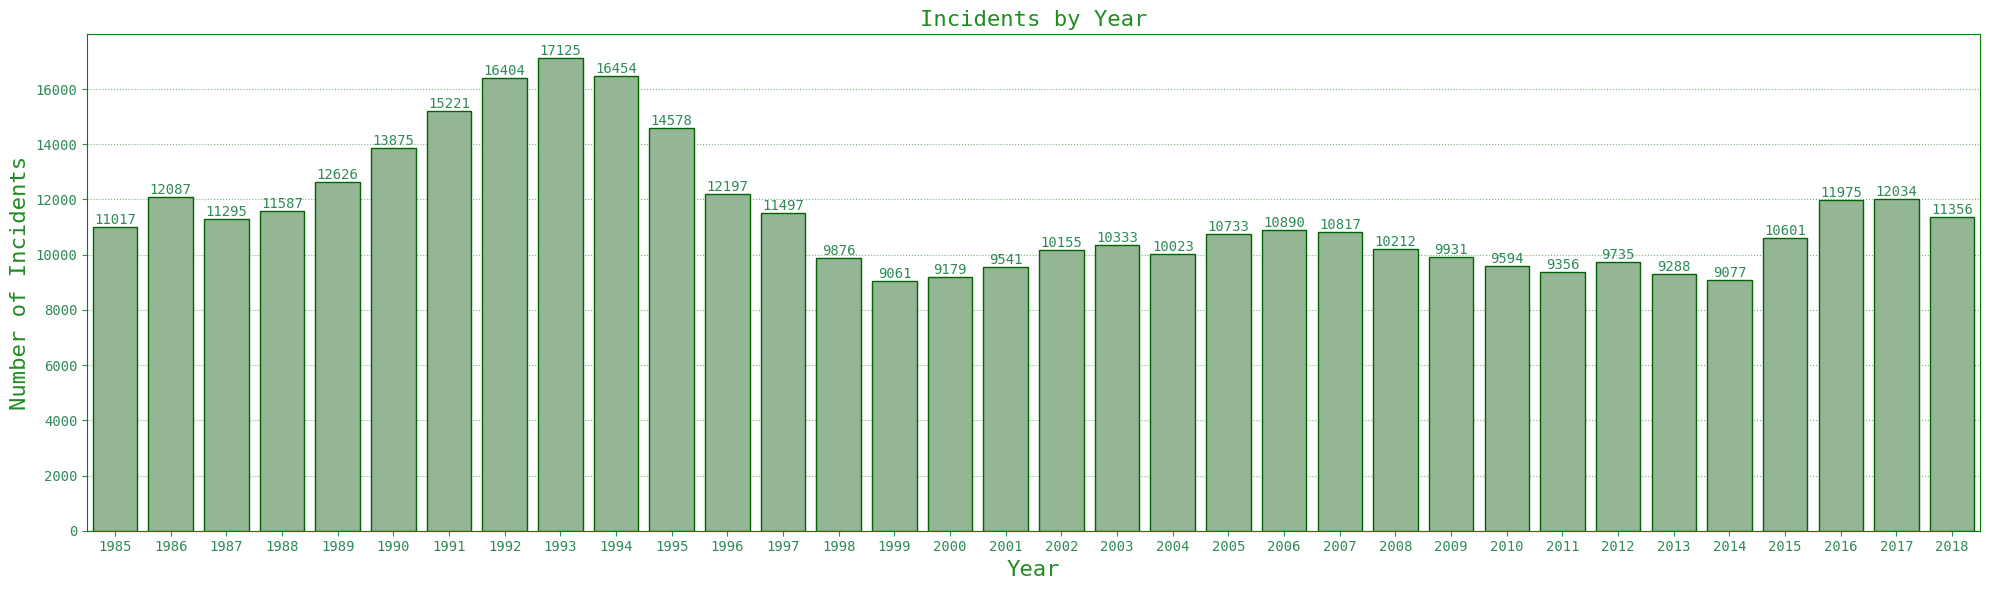

In [437]:
data = df.groupby('year')['incident_id'].count()
plt.figure(figsize=(20, 6))
ax = sns.barplot(x=data.index, y=data.values, zorder=3, color='darkseagreen', edgecolor='darkgreen')
plt.title('Incidents by Year',fontsize=16)
plt.xlabel('Year',fontsize=16)
plt.ylabel('Number of Incidents', fontsize=16)
for container in ax.containers:
   ax.bar_label(container, color='seagreen')
plt.grid(axis='y', zorder=0)
plt.tight_layout()
plt.show()

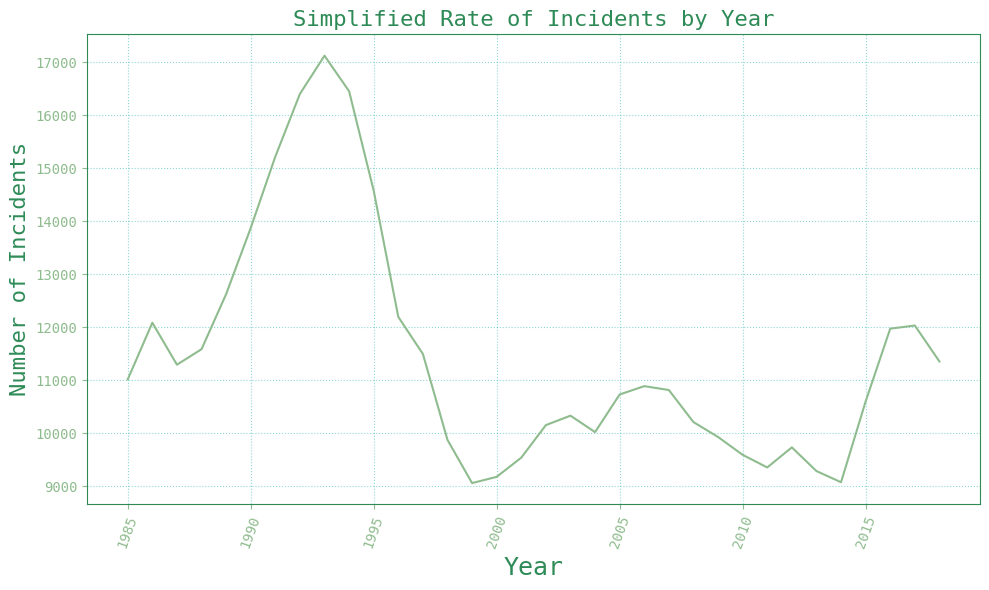

In [ ]:
data = df.groupby('year')['incident_id'].count()
plt.figure(figsize=(10, 6))
sns.lineplot(x=data.index, y=data.values, color='darkseagreen')
plt.title('Simplified Rate of Incidents by Year',fontsize=16,)
plt.xticks(rotation=70)
plt.yticks()
plt.xlabel('Year',fontsize=18)
plt.ylabel('Number of Incidents', fontsize=16)
plt.grid(zorder=1, alpha=0.5, color='lightseagreen', linestyle='dotted')
plt.tight_layout()
plt.show()

In [ ]:
#In these graphs, we can see a compartive increase before a downturn in incidents related to gun death. Reaching a peak between 1990 and 1995, it's maximum in 1993 before decreasing dramatically. We do see it picking back up around the 2010s.

In [ ]:
#Incident by Month (IBM) Analysis

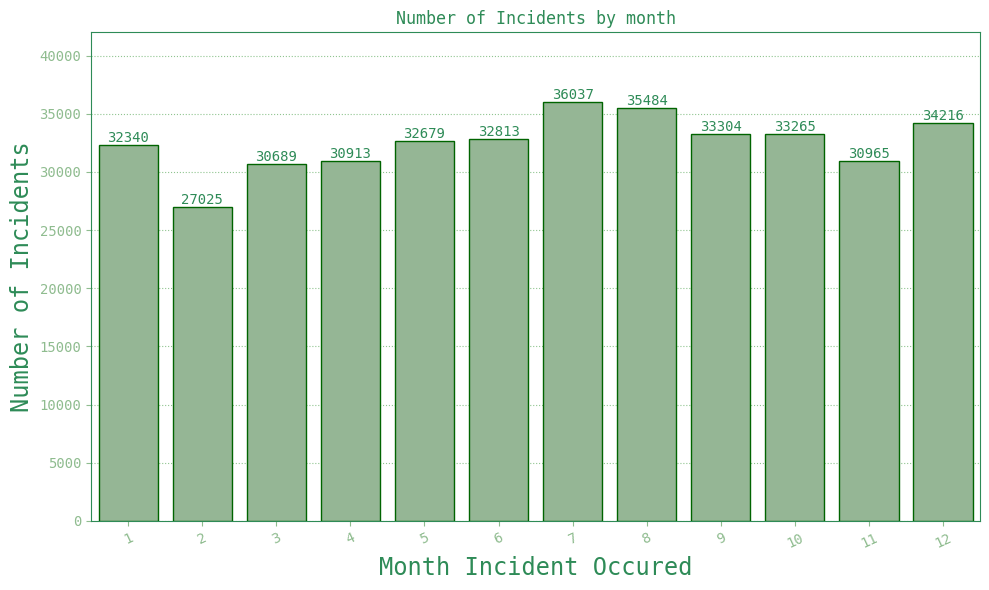

In [ ]:
data = df.groupby('month')['incident_id'].count()
incidents = data.reset_index()
incidents.columns = ['month', 'incident_id']

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='month', y='incident_id', data=incidents,color='darkseagreen', edgecolor='darkgreen', zorder=3, linewidth=1)
plt.xticks(rotation=25)
plt.title('Number of Incidents by month')
plt.xlabel('Month Incident Occured', fontsize=17)
plt.ylabel('Number of Incidents', fontsize=17)
for container in ax.containers:
   ax.bar_label(container, color='seagreen')
plt.grid(axis='y', zorder=0)
plt.ylim(0, 42000)
plt.tight_layout()
plt.show()

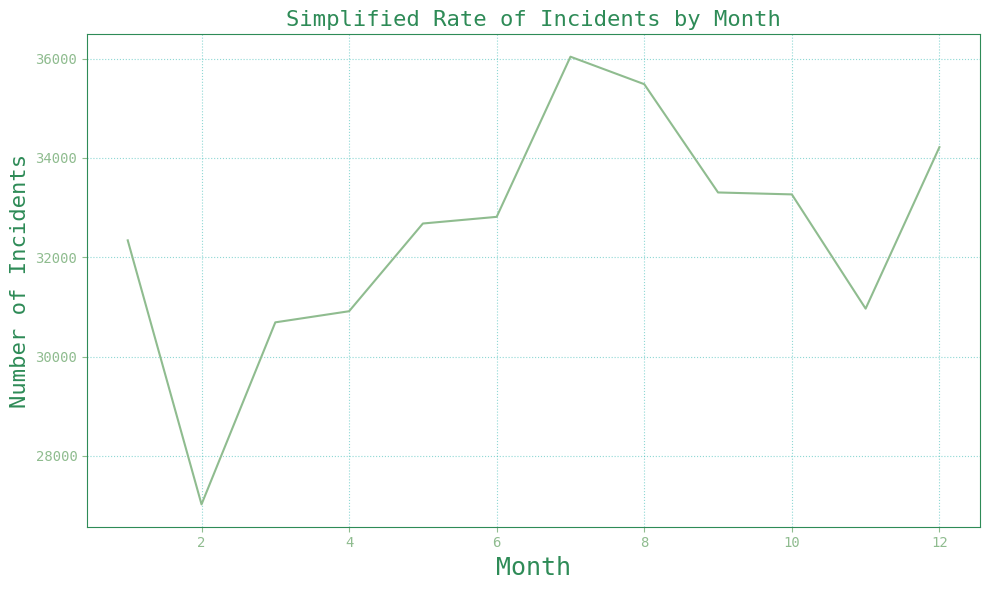

In [ ]:
data = df.groupby('month')['incident_id'].count()
incidents.columns = ['month', 'incident_id']

plt.figure(figsize=(10, 6))
plt.plot(incidents['month'], incidents['incident_id'], color='darkseagreen', zorder=3)
plt.title('Simplified Rate of Incidents by Month',fontsize=16,)
plt.yticks()
plt.xlabel('Month',fontsize=18)
plt.ylabel('Number of Incidents', fontsize=16)
plt.grid(zorder=1, alpha=0.5, color='lightseagreen', linestyle='dotted')
plt.tight_layout()
plt.show()

In [ ]:
#Condesning our data across the years into occurance by month has resulted in giving us information of what month in total tends to have a pattern of higher incidents compared to other months. We can see that February has the lowest occurances compared to July which which has the highest. We can see that across a calender year, incidents tend to follow a similar pattern as our year analysis, dipping before raising and then evening out.

In [ ]:
#Geological Analysis

In [ ]:
#In studying our data, it is not only important to conduct data by when it occurs, but where. In doing so, we can analyze where exactly these incidents occur.

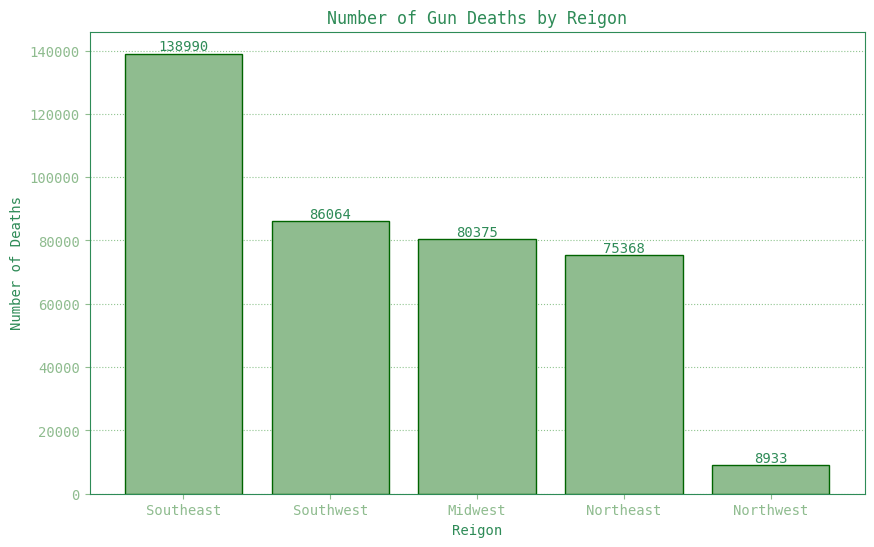

In [ ]:
reigondata = df.groupby('region')['incident_id'].count()
reigondata = reigondata.reset_index()
reigondata.columns = ['region', 'incident_id']
reigondata = reigondata.sort_values(by='incident_id', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(reigondata['region'], reigondata['incident_id'], color='darkseagreen', edgecolor='darkgreen', zorder=3)

plt.title('Number of Gun Deaths by Reigon')
plt.xlabel('Reigon')
plt.ylabel('Number of Deaths')
plt.bar_label(bars, color='seagreen')
plt.grid(axis='y', zorder=0)
plt.xticks()
plt.show()


In [ ]:
#In my findings, I was able to find out that the Southeast Region tends to have a pattern of higher rates of incident and gun violence compared to its Northern neighbors. In comparison, the Northwest having the lowest rate of incidence occurrence as a whole.


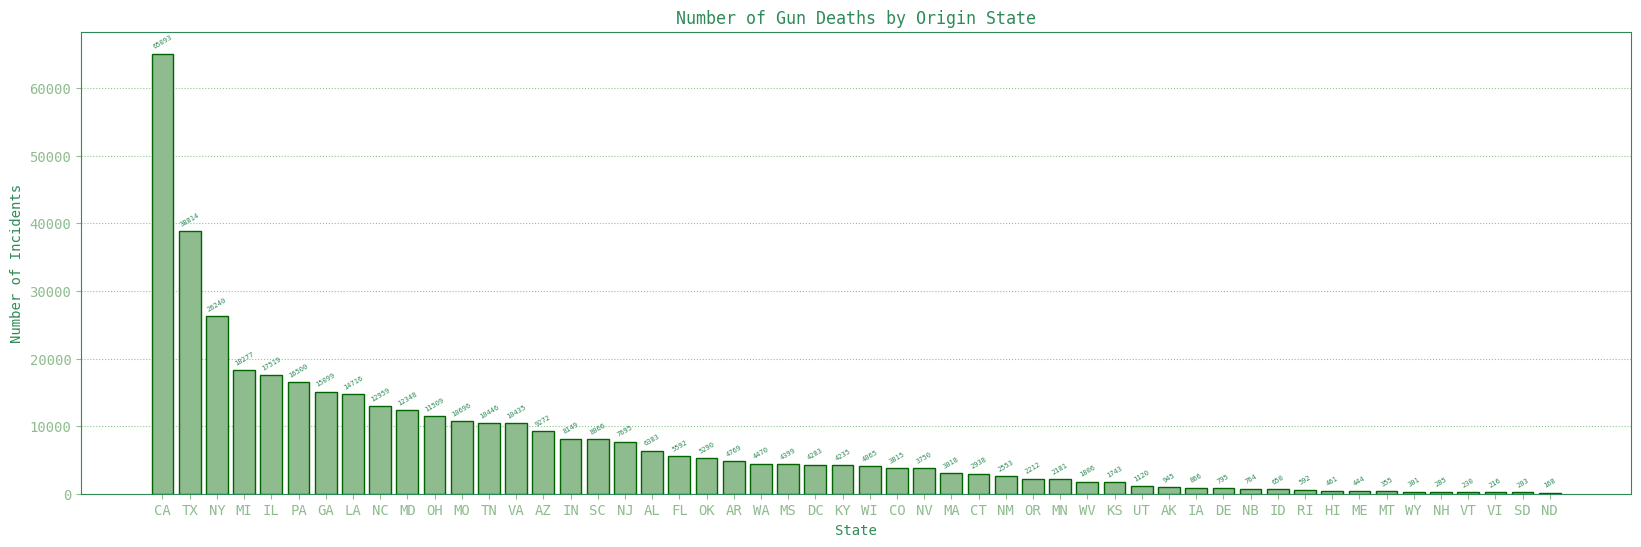

In [ ]:
statedata = df.groupby('state')['incident_id'].count()
statedata = statedata.reset_index()
statedata.columns = ['state', 'incident_id']
statedata = statedata.sort_values(by='incident_id', ascending=False)


plt.figure(figsize=(20, 6))
bars = plt.bar(statedata['state'], statedata['incident_id'], color='darkseagreen', edgecolor='darkgreen', zorder=3)
plt.title('Number of Gun Deaths by Origin State')
plt.xlabel('State')
plt.ylabel('Number of Incidents')
plt.bar_label(bars, padding=3,fontsize=5, rotation=30, color='seagreen')

plt.grid(axis='y', zorder=0)
plt.xticks()
plt.show()


In [ ]:
#We can see the connection between the previous graph and this one. Having states that are in the Southern regions having a higher rate of occurrence, ordering the bars we can see a noticeable downward turn that slopes negatively as we go from South -> Middle -> North.


In [ ]:
#Demographical Analysis
#I believe this is one of the more important parts, as it connects are data to actual living beings. From a demographic analysis, we can see which demographics of our society are more at risk to gun violence compared to others. We can ctergorize victims and offenders by their age, sex, race, and even relationship which provides background and nuance to our data. Unfortunately, out dataset does not provide the offender age or race, as such those will be omitted and our data will have a bias towards describing victims over offenders.

In [ ]:
#Age Analysis

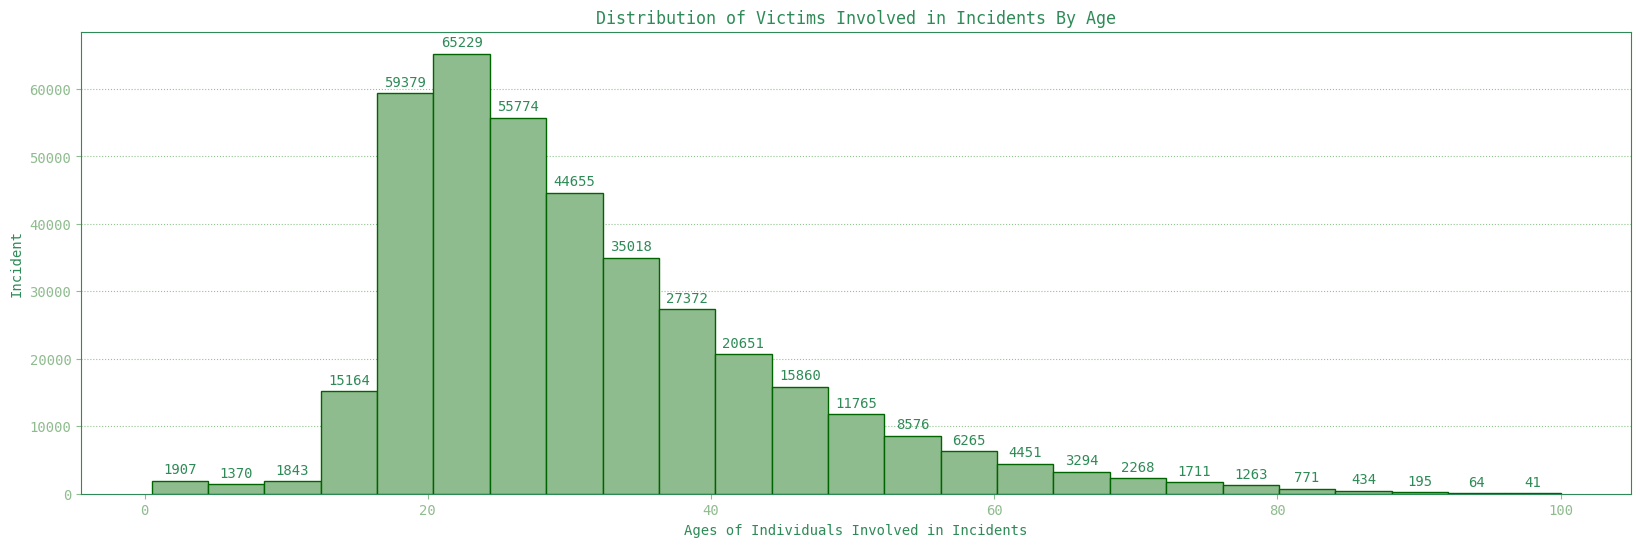

In [ ]:
data = df.groupby('victim_age')['incident_id'].count()
agedeaths = data.reset_index()
agedeaths.columns = ['year', 'incident_id']

plt.figure(figsize=(20, 6))
values, bins, bars = plt.hist(df['victim_age'], bins=25, color='darkseagreen', edgecolor='darkgreen', zorder=3)
plt.title('Distribution of Victims Involved in Incidents By Age')
plt.xlabel('Ages of Individuals Involved in Incidents')
plt.ylabel('Incident')
plt.grid(axis='y', zorder=0)
plt.bar_label(bars, padding=3, color='seagreen')


plt.show()

In [ ]:
#Going by ages, we can see the distribution in which victimhood occurs. Youths, being from the age range of less than 20 to less than thirty (>20~30) are at the highest risk of victimization in gun violence, with the highest. Where as victimhood significantly drops around an individual's 40s.

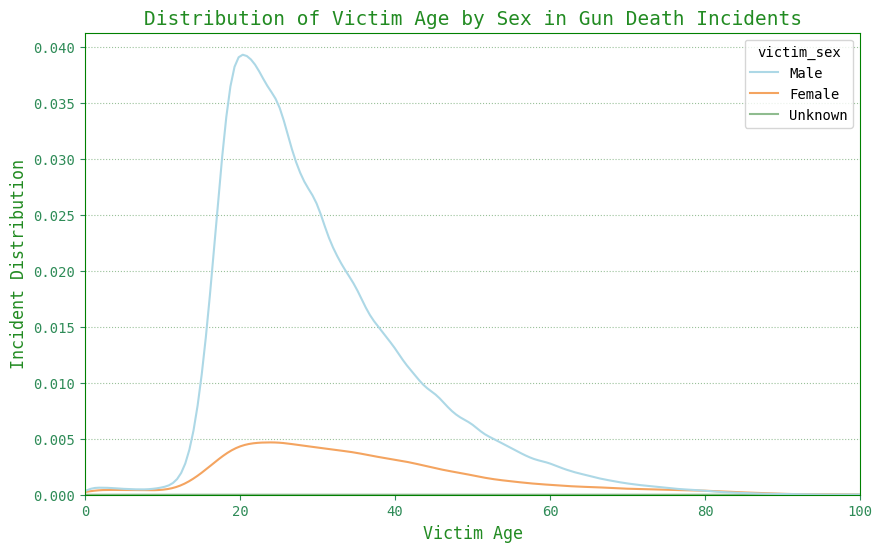

In [429]:
plt.figure(figsize=(10, 6))
sns.kdeplot(x='victim_age', hue='victim_sex', fill=False, data=df,  palette=['lightblue', 'sandybrown', 'darkseagreen'])

plt.title("Distribution of Victim Age by Sex in Gun Death Incidents", fontsize=14)
plt.xlabel("Victim Age", fontsize=12)
plt.ylabel("Incident Distribution", fontsize=12)
plt.grid(axis='y', alpha=0.4, zorder=0)
plt.xlim(0,100)
plt.show()

In [ ]:
#The last we have in our demographic analysis is a cross-analysis between age and incident occurrence. Continuing the trend, male youths are at the highest risk and incidents occur highest in the 20s~30s range of age demographics. Female youths, while at significantly less risk, share a similar pattern of age demographic and incident occurrence.


In [ ]:
#Sex Based Analysis

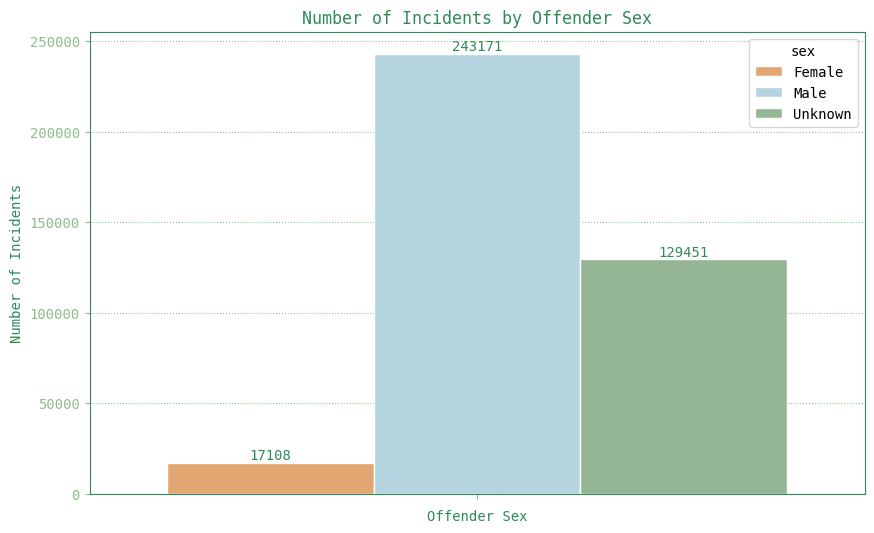

In [ ]:
osexdata = df.groupby('offender_sex')['incident_id'].count()
osex_data = osexdata.reset_index()
osex_data.columns = ['sex', 'offenders']

plt.figure(figsize=(10, 6))
ax = sns.barplot(hue='sex', y='offenders', zorder=3, edgecolor='white', data=osex_data, palette=['sandybrown', 'lightblue', 'darkseagreen'])
plt.title('Number of Incidents by Offender Sex')
plt.xlabel('Offender Sex')
plt.ylabel('Number of Incidents')
plt.grid(axis='y', zorder=0)
for container in ax.containers:
   ax.bar_label(container, color='seagreen')
plt.show()


In [ ]:
#Going by offenders, the perpetrators of these incidents, the highest offending sex by far are males. With the second highest being unknown. Interestingly, we can see that women commit the lowest amount of offenses.


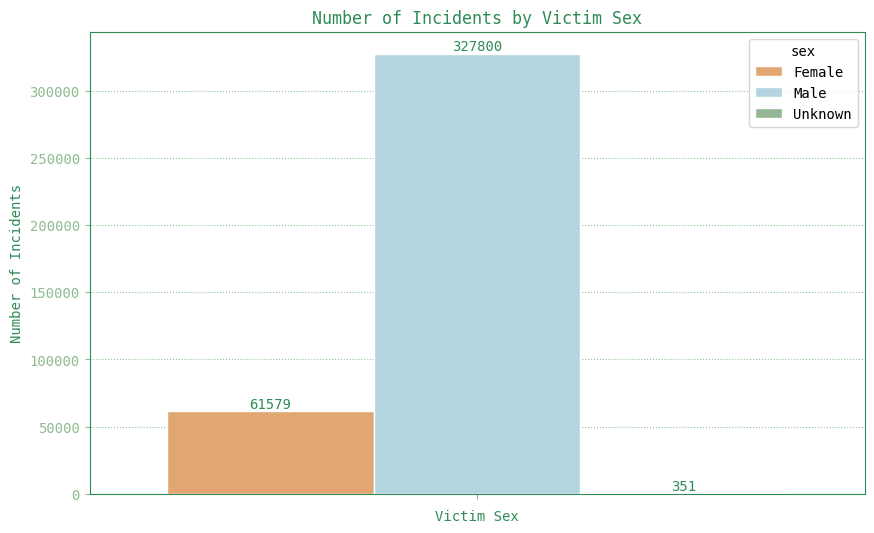

In [ ]:
vsexdata = df.groupby('victim_sex')['incident_id'].count()
vsex_data = vsexdata.reset_index()
vsex_data.columns = ['sex', 'victim']
plt.figure(figsize=(10, 6))
ax = sns.barplot(hue='sex', y='victim', zorder=3, edgecolor='white', data=vsex_data, palette=['sandybrown', 'lightblue', 'darkseagreen'])
plt.title('Number of Incidents by Victim Sex')
plt.xlabel('Victim Sex')
plt.ylabel('Number of Incidents')
plt.grid(axis='y', zorder=0)
for container in ax.containers:
   ax.bar_label(container, color='seagreen')
plt.show()


In [ ]:
#When we move over to victims, we see an interesting pattern. Men are not only the highest offenders, but the highest victims too. However, we do see that women commit offenses less

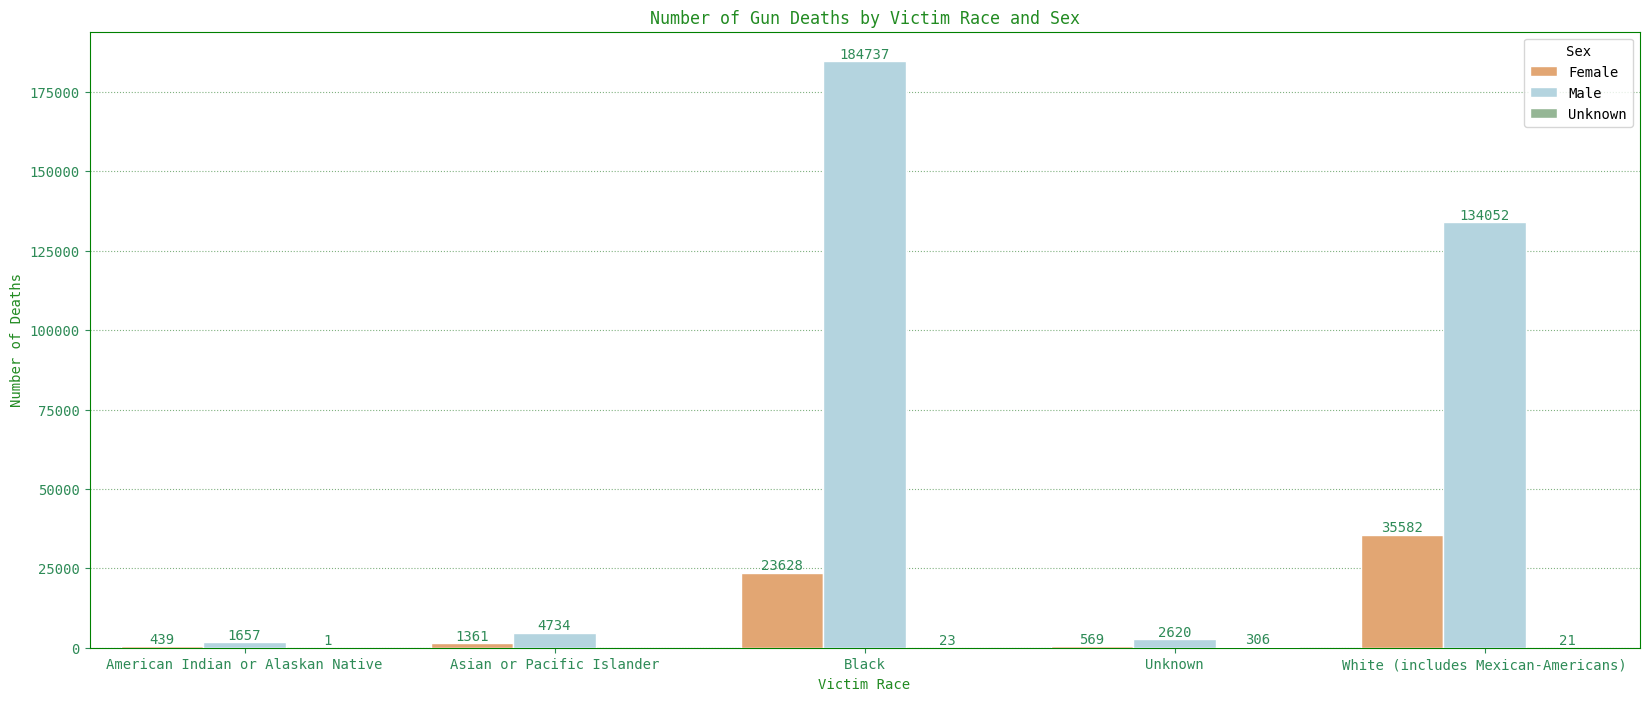

In [438]:
rvictim_sex = df.groupby(['victim_race', 'victim_sex'])['incident_id'].count().reset_index()
rvictim_sex.columns = ['victim_race', 'sex', 'victims']
plt.figure(figsize=(20, 8))
ax = sns.barplot(x='victim_race', y='victims', zorder=3, edgecolor='white', hue='sex', data=rvictim_sex,  palette=['sandybrown', 'lightblue', 'darkseagreen'])
plt.title('Number of Gun Deaths by Victim Race and Sex')
plt.xlabel('Victim Race')
plt.ylabel('Number of Deaths')
for container in ax.containers:
   ax.bar_label(container, color='seagreen')
plt.legend(title='Sex')
plt.grid(axis='y', zorder=0)
plt.show()

0

In [ ]:
#Moving onto victim race, I’ve decided to combine it with cross analysis with sex too. As a whole, we can see that Black American men and Black American women are at risk to victimhood in comparison as whole, with White Americans coming seconds. Asian or Pacific Islander Americans have the second lowest rates of victimhood with American Indian or Alaskan Natives coming at the lowest.


In [ ]:
heatmap_data = df.groupby(['state', 'victim_sex']).size().reset_index(name='Incidents')


In [ ]:
fig = px.choropleth(data_frame=heatmap_data, locations='state',
locationmode='USA-states', color='Incidents', color_continuous_scale='greens',  facet_col='victim_sex', scope='usa', title='Gun Deaths by State and Victim Sex')
#fig.show()

In [ ]:
#I would like to show of a series of heatmaps that describe victims to incidents and measures them by race, and as seen we notice that Male Victims tend to have a higher rate of incident occurrence compared to Female Victims.


In [ ]:
#Relational and Misc Analysis

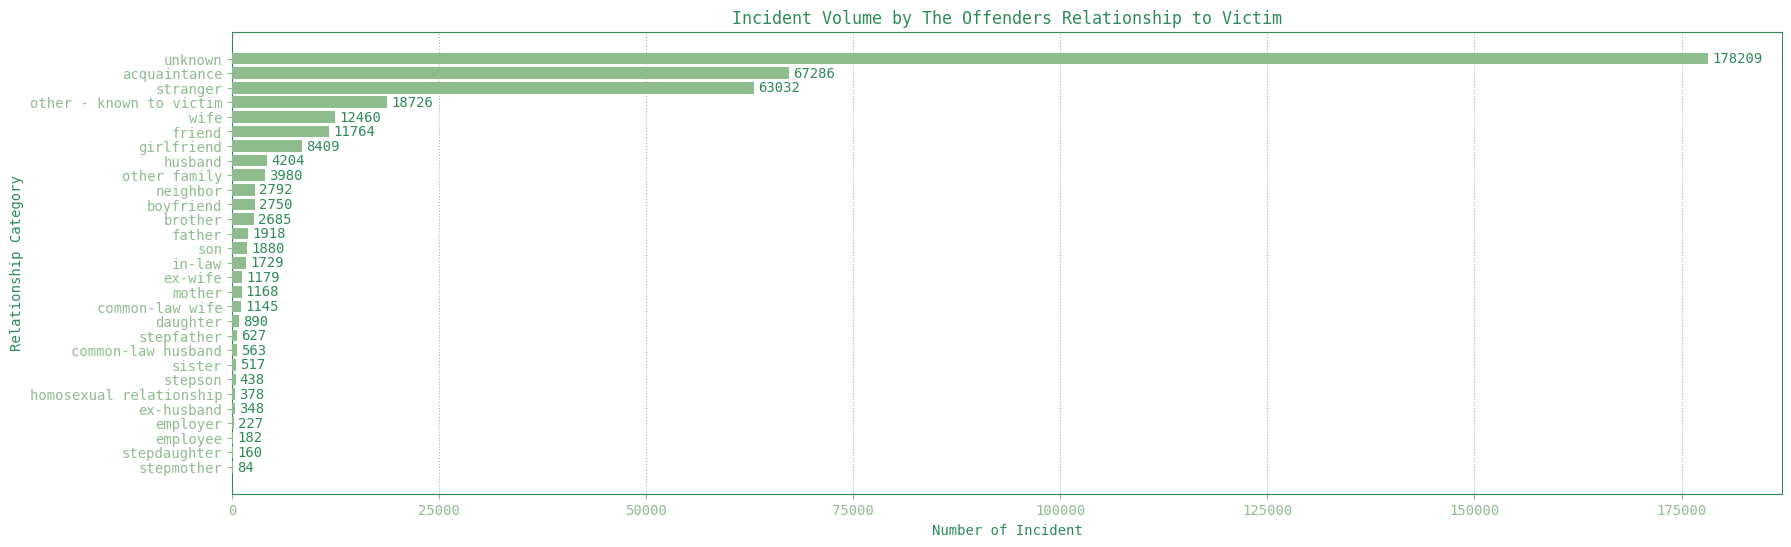

In [ ]:
data = df.groupby('offenders_relationship_to_victim')['incident_id'].count()
relationship_category = data.reset_index()
relationship_category.columns = ['offenders_relationship_to_victim', 'incident_id']
relationship_category = relationship_category.sort_values(by='incident_id', ascending=True)

plt.figure(figsize=(20, 6))
bars = plt.barh(relationship_category['offenders_relationship_to_victim'], relationship_category['incident_id'], color='darkseagreen', zorder=3)
plt.title('Incident Volume by The Offenders Relationship to Victim')
plt.xlabel('Number of Incident')
plt.ylabel('Relationship Category')
plt.bar_label(bars, color='seagreen', padding=3)
plt.grid(axis='x', zorder=0)
plt.show()

In [ ]:
#While an overwhelming majority of our offenders’ victims tend to be listed as unknown we can see under an actual description, we can see a lot of these incidents involve a acquaintance or stranger. However, in a family unit, we can see that wives have a higher rate of victimhood compared to husbands. However, fathers are at a higher risk of victimhood compared to mothers. Continuing, we can see that in the family unit brothers and sisters, sons and daughters follow this similar pattern too.
#Following this, we can see how this may foreshadow in how sex-based victim and offense demographics tend to shape-up.


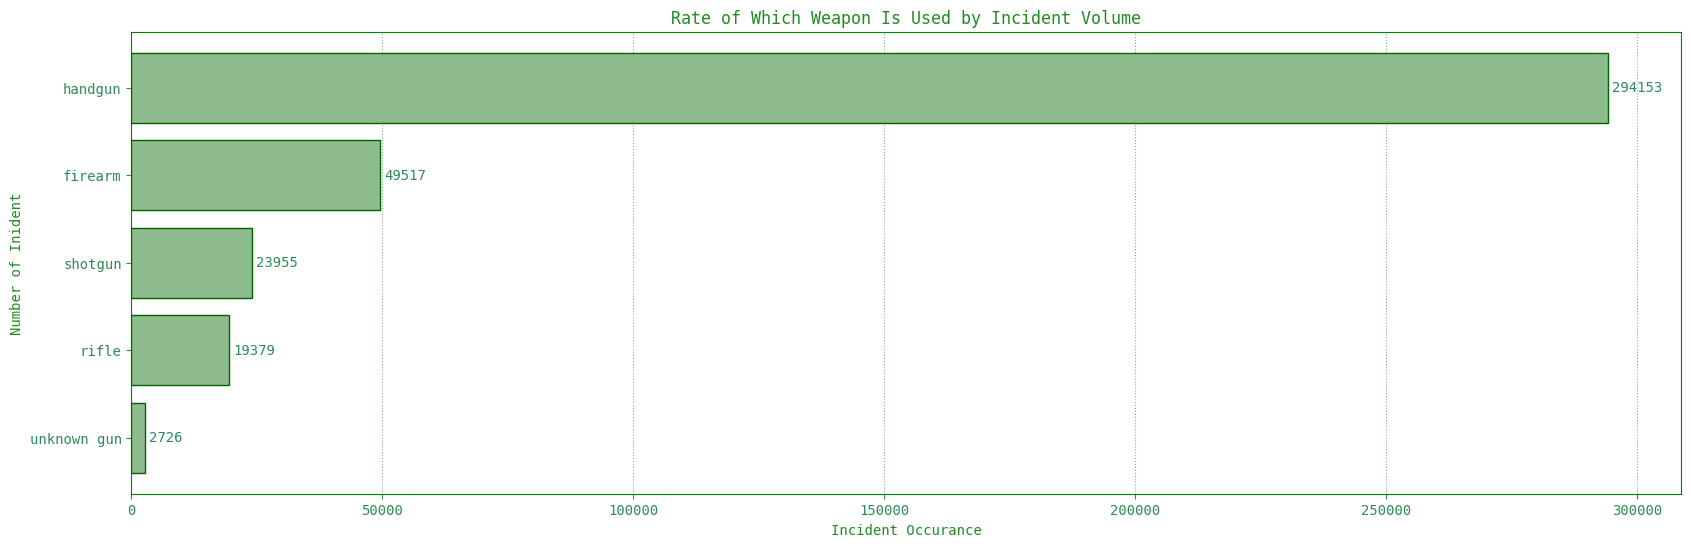

In [435]:
#Foundational Code
weapondata = df.groupby('weapon_used')['incident_id'].count()
weapondata = weapondata.reset_index()
weapondata.columns = ['weapon_used', 'incident_id']
weapondata = weapondata.sort_values(by='incident_id', ascending=True)

plt.figure(figsize=(20, 6))
bars = plt.barh(weapondata['weapon_used'], weapondata['incident_id'], color='darkseagreen', edgecolor='darkgreen',zorder=3)
plt.title('Rate of Which Weapon Is Used by Incident Volume')
plt.xlabel('Incident Occurance')
plt.ylabel('Number of Inident')
plt.bar_label(bars, color='seagreen', padding=3)
plt.grid(axis='x', zorder=0)
plt.show()

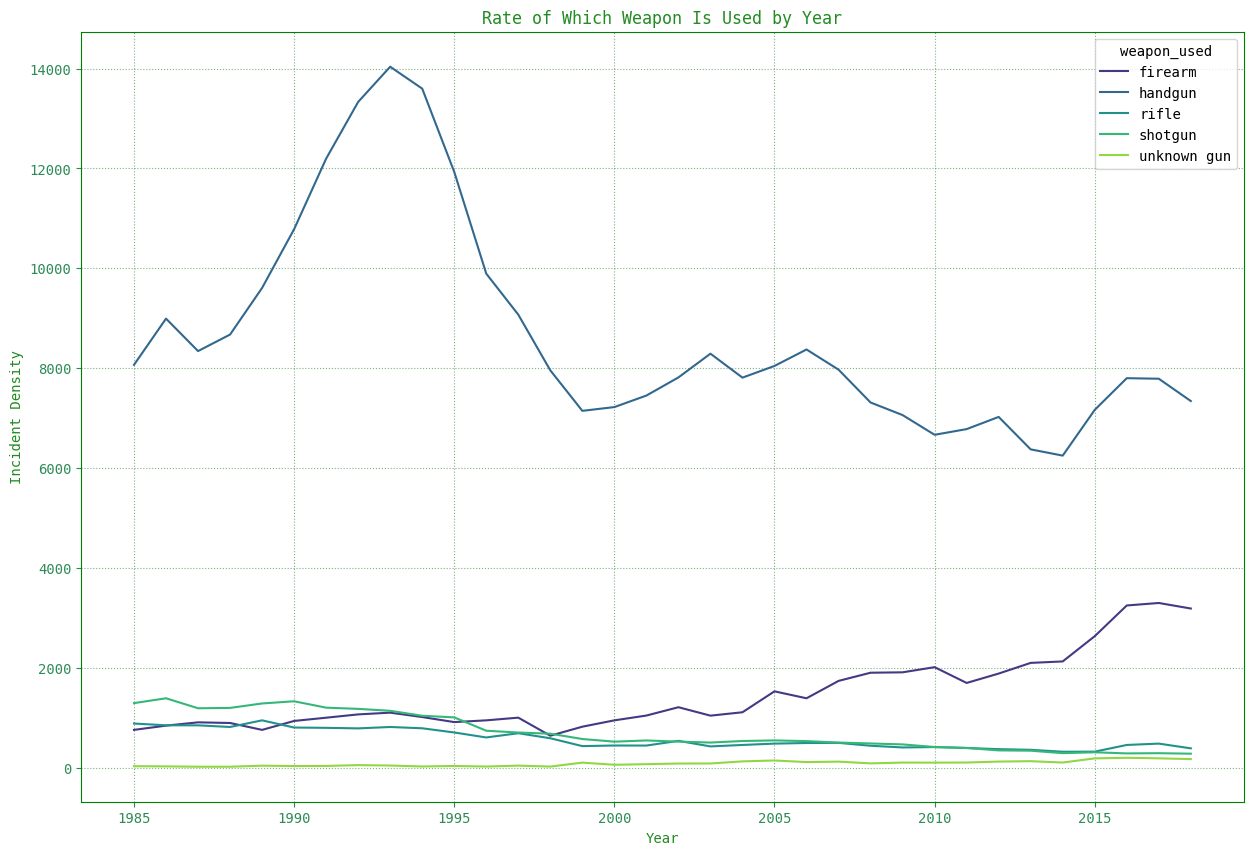

In [432]:
plt.figure(figsize=(15, 10))
weapon_by_year = df.groupby(['year', 'weapon_used'])['incident_id'].count().reset_index(name='incident_count')

sns.lineplot(data=weapon_by_year, x='year', y='incident_count', hue='weapon_used', palette='viridis')

plt.title('Rate of Which Weapon Is Used by Year')
plt.xlabel('Year')
plt.ylabel('Incident Density')
plt.grid(zorder=0)
plt.tight_layout
plt.show()


In [ ]:
#Finally, to end our chronological analysis I’ve cross analyzed the occurrence of incident with each weapon used over a period of 1985 to 2017. With this, we can see trends in which weapons spiked in popularity compared to others, however, above all else handguns have and possibly will always continue to be popular
